In [1]:
# Important libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for beautiful data visualization
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Flight Price Prediction using Machine Learning

This notebook predicts flight ticket prices using different machine learning models. The notebook includes data preprocessing, visualization, feature engineering, model building, hyperparameter tuning, and comparison of model performance.

In [2]:
# Accesing Dataset and loading them into appropriate dataframes.
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

        
# data frame for the training dataset
train_data = pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv")

# Data frame for the test dataset (i.e. without the target variable)
test_data = pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv")

# Data frame of labels of the test dataset (i.e. only target variable)
sample = pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/sample_submission.csv") 




/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv


# **Exploratory Data Analysis**

In [3]:
# Information regarding training data which we will going to use to train our model.
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


In [4]:
# Display last first rows
train_data.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584


In [5]:
# Display last five rows
train_data.tail()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
39995,39995,Vistara,UK-940,Mumbai,NaN,one,Evening,Bangalore,Economy,21.25,43.0,6450
39996,39996,Vistara,UK-720,Kolkata,Early_Morning,one,Night,Mumbai,Business,14.08,12.0,64831
39997,39997,NaN,UK-874,Hyderabad,Morning,one,Night,Bangalore,Economy,14.33,NaN,8062
39998,39998,Vistara,UK-940,Mumbai,NaN,one,Night,Bangalore,Business,24.67,4.0,84557
39999,39999,GO_FIRST,G8-511,Mumbai,Early_Morning,one,Evening,Bangalore,Economy,14.33,NaN,5102


In [6]:

train_data.shape

(40000, 12)

In [7]:
train_data.dtypes

id               int64
airline         object
flight          object
source          object
departure       object
stops           object
arrival         object
destination     object
class           object
duration       float64
days_left      float64
price            int64
dtype: object

### Observation

The dataset contains both numerical and categorical features.

Numerical columns include:

- id
- duration
- days_left
- price

Categorical columns include:

- airline
- flight
- source
- departure
- stops
- arrival
- destination
- class



In [8]:
# Statistical Summary

train_data.describe()

,id,duration,days_left,price
count,40000.00000,36987.000000,35562.000000,40000.00000
mean,19999.50000,12.004088,26.197936,20801.49025
std,11547.14972,7.108063,13.469232,22729.14842
min,0.00000,0.830000,1.000000,1105.00000
25%,9999.75000,6.670000,15.000000,4687.00000
50%,19999.50000,11.080000,26.000000,7353.00000
75%,29999.25000,15.920000,38.000000,42521.00000
max,39999.00000,47.080000,49.000000,114704.00000


In [9]:
# Median of Numerical Columns

train_data.median(numeric_only=True)

id           19999.50
duration        11.08
days_left       26.00
price         7353.00
dtype: float64

### Observation

The descriptive statistics provide useful information such as the mean, median, minimum, maximum, and standard deviation of numerical features.

These statistics help in understanding the overall distribution of the data before preprocessing.

In [10]:
# detecting missing data
test_data.isnull().sum()

id               0
airline        548
flight           0
source           0
departure      920
stops          651
arrival          0
destination      0
class            0
duration       582
days_left      696
dtype: int64

## Missing Values

Missing values were found in both numerical and categorical columns.

- Numerical columns (`duration` and `days_left`) were filled using the **median** because it is less affected by outliers.
- Categorical columns (`airline`, `departure`, and `stops`) were filled using the **mode**, which replaces missing values with the most frequently occurring category.

In [11]:
# ==========================================
# Handling Missing Values
# ==========================================

# Fill numerical columns with median
train_data["duration"] = train_data["duration"].fillna(train_data["duration"].median())
train_data["days_left"] = train_data["days_left"].fillna(train_data["days_left"].median())

# Fill categorical columns with mode
train_data["airline"] = train_data["airline"].fillna(train_data["airline"].mode()[0])
train_data["departure"] = train_data["departure"].fillna(train_data["departure"].mode()[0])
train_data["stops"] = train_data["stops"].fillna(train_data["stops"].mode()[0])



In [12]:
# Fill missing values in test data

test_data["duration"] = test_data["duration"].fillna(train_data["duration"].median())
test_data["days_left"] = test_data["days_left"].fillna(train_data["days_left"].median())

test_data["airline"] = test_data["airline"].fillna(train_data["airline"].mode()[0])
test_data["departure"] = test_data["departure"].fillna(train_data["departure"].mode()[0])
test_data["stops"] = test_data["stops"].fillna(train_data["stops"].mode()[0])

In [13]:
train_data.isnull().sum()

id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
price          0
dtype: int64

# Duplicate Values

Duplicate rows can affect the performance of machine learning models by giving more importance to repeated observations. Therefore, duplicate rows are identified and removed if present.

In [14]:
# ==========================================
# Checking Duplicate Values
# ==========================================

duplicate_count = train_data.duplicated().sum()

print("Number of Duplicate Rows :", duplicate_count)

Number of Duplicate Rows : 0


### Observation

No duplicate rows were found in the dataset. Therefore, no rows were removed.

# Outlier Analysis

Boxplots are used to identify potential outliers in numerical features. Outliers are values that are significantly different from the rest of the observations.

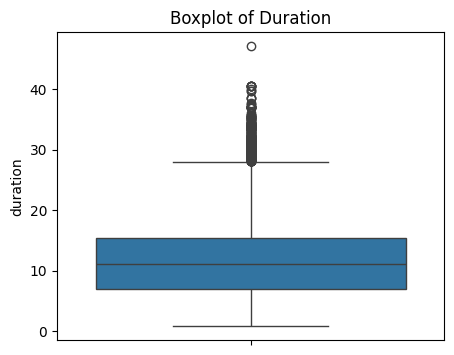

In [15]:
# ==========================================
# Boxplot for Duration
# ==========================================

plt.figure(figsize=(5,4))
sns.boxplot(y=train_data["duration"])
plt.title("Boxplot of Duration")
plt.show()

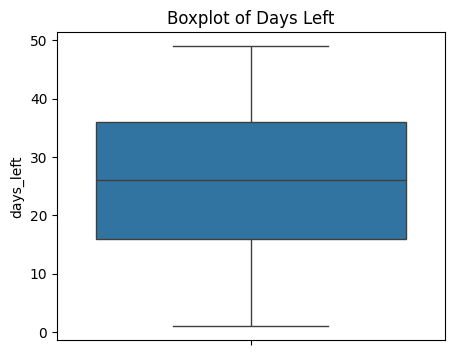

In [16]:
# ==========================================
# Boxplot for Days Left
# ==========================================

plt.figure(figsize=(5,4))
sns.boxplot(y=train_data["days_left"])
plt.title("Boxplot of Days Left")
plt.show()

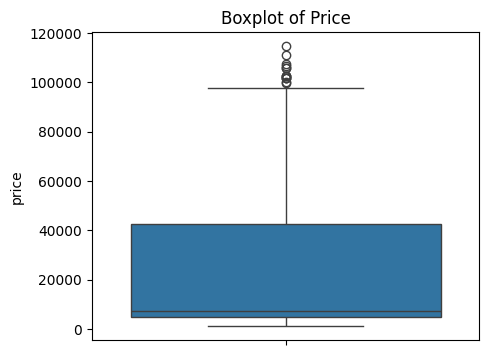

In [17]:
# ==========================================
# Boxplot for Price
# ==========================================

plt.figure(figsize=(5,4))
sns.boxplot(y=train_data["price"])
plt.title("Boxplot of Price")
plt.show()

### Observation

The boxplots show that the numerical features contain some outliers. These outliers are expected because flight prices and travel duration naturally vary depending on the airline, route, and travel class. Therefore, the outliers were retained.

# Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of the data and identify important patterns before building machine learning models.

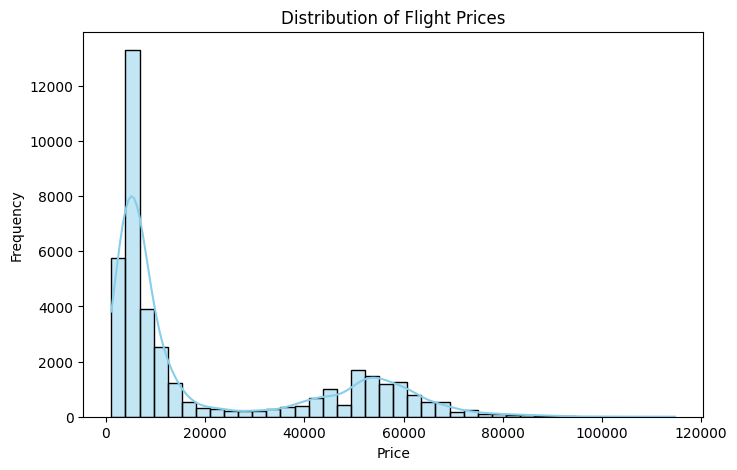

In [18]:
# ==========================================
# Distribution of Flight Prices
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(train_data["price"], bins=40, kde=True, color="skyblue")

plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Insight

Most flight ticket prices are concentrated in the lower price range (around ₹2,000–₹12,000). Another smaller peak is observed around ₹45,000–₹60,000, indicating the presence of higher-priced flights such as Business Class. Very expensive flights are comparatively fewer.

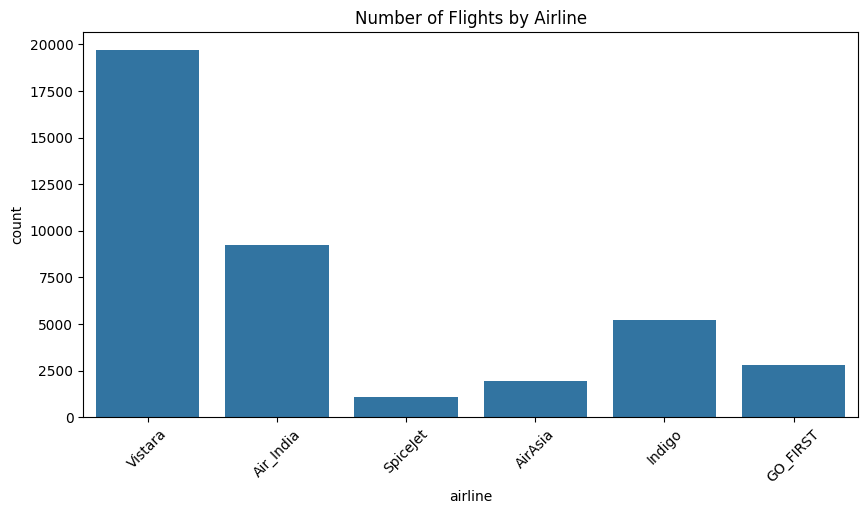

In [19]:
# ==========================================
# Number of Flights by Airline
# ==========================================

plt.figure(figsize=(10,5))

sns.countplot(x="airline", data=train_data)

plt.title("Number of Flights by Airline")
plt.xticks(rotation=45)

plt.show()

### Insight

Some airlines have significantly more flight records than others. This shows that the dataset is not equally distributed among airlines.

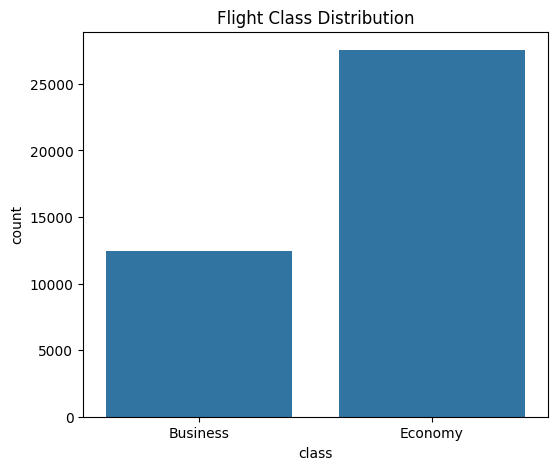

In [20]:
# ==========================================
# Flight Class Distribution
# ==========================================

plt.figure(figsize=(6,5))

sns.countplot(x="class", data=train_data)

plt.title("Flight Class Distribution")

plt.show()

### Insight

The dataset contains both Economy and Business class flights. Economy class appears more frequently than Business class.

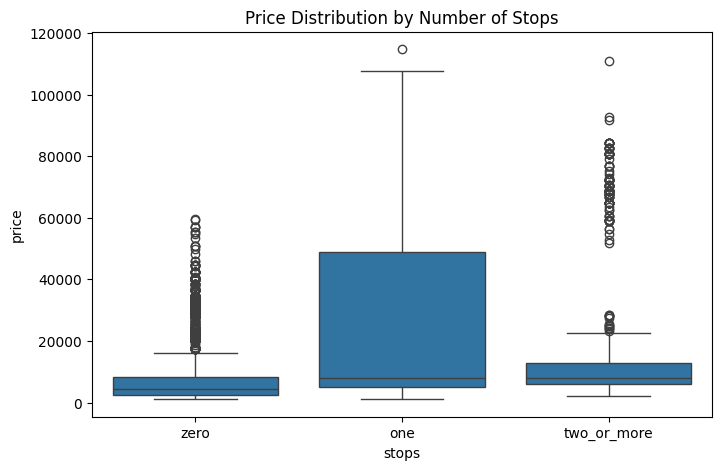

In [21]:
# ==========================================
# Stops vs Price
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(x="stops", y="price", data=train_data, order=["zero", "one", "two_or_more"])

plt.title("Price Distribution by Number of Stops")

plt.show()

### Insight

The ticket price varies with the number of stops. One-stop flights show the highest variation in ticket prices, while non-stop flights generally have lower prices. A few very expensive tickets are present as outliers, which are expected in real-world flight data.

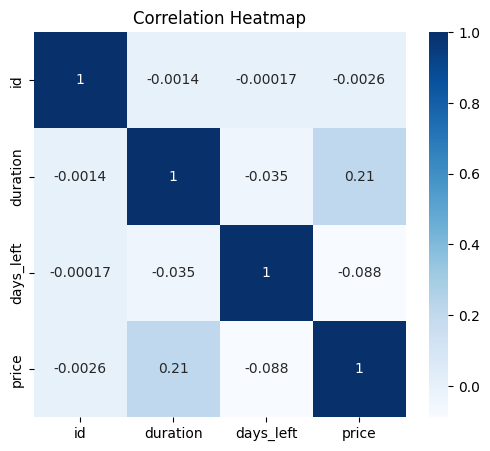

In [22]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(train_data.corr(numeric_only=True),
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

### Insight

The correlation heatmap shows that there is no strong correlation among the numerical features. Duration has a weak positive correlation (0.21) with the ticket price, while days_left has a very weak negative correlation (-0.088) with price. The id column has almost no relationship with the target variable.

# Data Preprocessing

Before training machine learning models, the dataset is prepared by separating the input features and the target variable. The target variable is **price**, while the remaining columns are used as input features.

In [23]:
# ==========================================
# Separate Features and Target
# ==========================================

X = train_data.drop("price", axis=1)
y = train_data["price"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (40000, 11)
Target Shape : (40000,)


In [24]:
#Remove id coloumn

X = X.drop(columns=["id"], errors="ignore")
test_data = test_data.drop(columns=["id"], errors="ignore")

### Observation

The **id** column is only a unique identifier and does not contribute to predicting flight prices. Therefore, it was removed before training the models.

In [25]:
# Categorical Columns

X.select_dtypes(include="object").columns

Index(['airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class'],
      dtype='object')

## Encoding Categorical Features

Machine learning models cannot work directly with text data. Therefore, categorical columns are converted into numerical format using One-Hot Encoding. This method creates separate binary columns for each category without introducing any order among the categories.

In [26]:
# ==========================================
# One-Hot Encoding
# ==========================================

X = pd.get_dummies(X, drop_first=True)
test_data = pd.get_dummies(test_data, drop_first=True)


In [27]:
# Make train and test have exactly the same columns

X, test_data = X.align(test_data, join="left", axis=1, fill_value=0)

In [28]:
print(X.shape)
print(test_data.shape)

(40000, 898)
(10000, 898)


In [29]:
print(test_data.isnull().sum())

duration                 0
days_left                0
airline_Air_India        0
airline_GO_FIRST         0
airline_Indigo           0
                        ..
destination_Delhi        0
destination_Hyderabad    0
destination_Kolkata      0
destination_Mumbai       0
class_Economy            0
Length: 898, dtype: int64


## Feature Scaling

Numerical features are scaled using StandardScaler. Scaling helps machine learning algorithms perform better by bringing numerical features to a similar range. Tree-based models do not require scaling, but it is useful for models such as Linear Regression, KNN, and Support Vector Regression.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)
test_data = scaler.transform(test_data)



In [31]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Validation Shape :", X_valid.shape)

Training Shape : (32000, 898)
Validation Shape : (8000, 898)


In [32]:
# ==========================================
# Import Machine Learning Models
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

In [33]:
# ==========================================
# Linear Regression
# ==========================================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_valid)

print("Linear Regression")


print("R2 Score :", r2_score(y_valid, lr_pred))

Linear Regression
R2 Score : 0.921347624466048


In [34]:
# ==========================================
# Decision Tree
# ==========================================

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_valid)

print("Decision Tree")


print("R2 Score :", r2_score(y_valid, dt_pred))

Decision Tree
R2 Score : 0.9593120354521676


In [35]:
# ==========================================
# Random Forest
# ==========================================

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)

print("Random Forest")


print("R2 Score :", r2_score(y_valid, rf_pred))

Random Forest
R2 Score : 0.9755236428086022


In [36]:
# ==========================================
# Gradient Boosting
# ==========================================

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_valid)

print("Gradient Boosting")


print("R2 Score :", r2_score(y_valid, gb_pred))

Gradient Boosting
R2 Score : 0.9490382400764245


In [37]:
# ==========================================
# Extra Trees
# ==========================================

et = ExtraTreesRegressor(random_state=42)

et.fit(X_train, y_train)

et_pred = et.predict(X_valid)

print("Extra Trees")


print("R2 Score :", r2_score(y_valid, et_pred))

Extra Trees
R2 Score : 0.9719050774606396


In [38]:
# ==========================================
# KNN
# ==========================================

knn = KNeighborsRegressor()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_valid)

print("KNN")

print("R2 Score :", r2_score(y_valid, knn_pred))

KNN
R2 Score : 0.7915643737033818


In [39]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(random_state=42)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_valid)

print("AdaBoost")
print("R2 Score:", r2_score(y_valid, ada_pred))

AdaBoost
R2 Score: 0.9271617174882114


## Observation

Seven different regression models were trained on the training dataset. Their performances were evaluated using R² Score. These results will be compared to select the best-performing model.

In [40]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best R2 Score:", rf_grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best R2 Score: 0.9749153348077227


In [41]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesRegressor
et_params = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20, None]
}

et_random = RandomizedSearchCV(
    ExtraTreesRegressor(random_state=42),
    et_params,
    n_iter=4,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

et_random.fit(X_train, y_train)

print(et_random.best_params_)
print(et_random.best_score_)

{'n_estimators': 150, 'max_depth': None}
0.9727314013568292


In [42]:
from sklearn.model_selection import RandomizedSearchCV

dt_params = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_random = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    n_iter=5,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

dt_random.fit(X_train, y_train)

print(dt_random.best_params_)
print(dt_random.best_score_)

{'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None}
0.9609497851029646


## Hyperparameter Tuning

Hyperparameter tuning was performed using GridSearchCV on the three best-performing models: Random Forest, Extra Trees, and Decision Tree. The best parameter combinations were selected based on the highest cross-validation R² score.

In [43]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees",
        "KNN",
        "AdaBoost"
    ],
    "R2 Score": [
        0.921347624466048,
        0.9593120354521676,
        0.9755236428086022,
        0.9490382400764245,
        0.9719050774606396,
        0.7915643737033818,
        0.9271617174882114
    ]
})

comparison = comparison.sort_values(by="R2 Score", ascending=False)

comparison

,Model,R2 Score
2,Random Forest,0.975524
4,Extra Trees,0.971905
1,Decision Tree,0.959312
3,Gradient Boosting,0.949038
6,AdaBoost,0.927162
0,Linear Regression,0.921348
5,KNN,0.791564


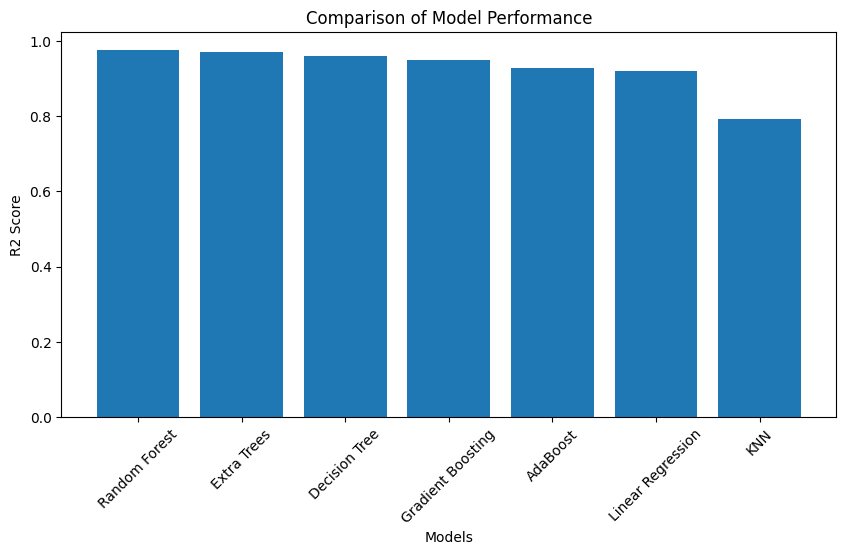

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("Comparison of Model Performance")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.xticks(rotation=45)

plt.show()

In [45]:
print(test_data.shape)

(10000, 898)


In [46]:
test_predictions = rf.predict(test_data)

In [47]:
submission = sample.copy()

submission["price"] = test_predictions

submission.head()

,id,price
0,0,4518.43
1,1,12301.40
2,2,5354.60
3,3,61153.21
4,4,49748.00


In [48]:
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!
